In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler

SEED = 1234
sns.set(style="whitegrid")


In [3]:
df = pd.read_csv('cleaned_reviews_sampled_preprocessed.csv')
df.head()


,id,text,rating,title,likes,consumersReviewCountOnSameDomain,consumersReviewCountOnSameLocation,company_name,labels.verification.isVerified,labels.verification.createdDateTime,...,consumer.countryCode,consumer.isVerified,reply.message,reply.publishedDate,reply.updatedDate,location.id,location.name,location.urlFormattedName,continent,clean_text
0,682695d01aadcf94ec3aea94,The tariff. I'm cancelling as soon as I burn t...,1,Tariff = Nope.,0,1,0,fabletics,True,2025-05-16 03:33:04+00:00,...,US,False,"Hello Gwendolyn,\n\nThank you for sharing your...",2025-05-17 04:00:20+00:00,NaN,NaN,NaN,NaN,North America,tariff cancelling soon burn last credit
1,662a212bddb79d3a3b1ead31,I've given a 3 because I'm waiting to make my ...,3,I've given a 3 because I'm waiting to…,0,1,0,freecash,True,2024-04-25 11:23:56+00:00,...,GB,False,NaN,NaN,NaN,NaN,NaN,NaN,Europe,given three waiting make first shout unfortuna...
2,67facfac6e18b4a46adc5750,Nice application for me,5,Nice,0,1,0,freecash,True,2025-04-12 22:40:12+00:00,...,CA,False,NaN,NaN,NaN,NaN,NaN,NaN,North America,nice application
3,5afb76de6d33bc0b083fa127,Easy ordering and customer service is the BEST,5,Easy ordering and customer service is…,0,1,0,cafepress,True,2018-05-16 00:10:06+00:00,...,US,False,NaN,NaN,NaN,NaN,NaN,NaN,North America,easy ordering customer service best
4,59f20aa0dc938904f8e20519,Very Good !!!,5,Very Good !!!,0,1,0,aliexpress.json,True,2017-10-26 16:17:36+00:00,...,RU,False,NaN,NaN,NaN,NaN,NaN,NaN,Asia,good


In [4]:
df_short = df[['id', 'rating', 'company_name', 'text', 'clean_text']]
df_short.head()

,id,rating,company_name,text,clean_text
0,682695d01aadcf94ec3aea94,1,fabletics,The tariff. I'm cancelling as soon as I burn t...,tariff cancelling soon burn last credit
1,662a212bddb79d3a3b1ead31,3,freecash,I've given a 3 because I'm waiting to make my ...,given three waiting make first shout unfortuna...
2,67facfac6e18b4a46adc5750,5,freecash,Nice application for me,nice application
3,5afb76de6d33bc0b083fa127,5,cafepress,Easy ordering and customer service is the BEST,easy ordering customer service best
4,59f20aa0dc938904f8e20519,5,aliexpress.json,Very Good !!!,good


In [5]:
categorie_rating = {1: 'poor', 2: '0', 3: '0', 4: '0', 5: 'good'}
df_short['ratings_categorie'] = df_short['rating'].map(categorie_rating)
df_short.head()

C:\Users\Yalda\AppData\Local\Temp\ipykernel_15016\785471167.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_short['ratings_categorie'] = df_short['rating'].map(categorie_rating)


,id,rating,company_name,text,clean_text,ratings_categorie
0,682695d01aadcf94ec3aea94,1,fabletics,The tariff. I'm cancelling as soon as I burn t...,tariff cancelling soon burn last credit,poor
1,662a212bddb79d3a3b1ead31,3,freecash,I've given a 3 because I'm waiting to make my ...,given three waiting make first shout unfortuna...,0
2,67facfac6e18b4a46adc5750,5,freecash,Nice application for me,nice application,good
3,5afb76de6d33bc0b083fa127,5,cafepress,Easy ordering and customer service is the BEST,easy ordering customer service best,good
4,59f20aa0dc938904f8e20519,5,aliexpress.json,Very Good !!!,good,good


In [6]:
df_short.info()
df_short = df_short.dropna()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 25000 non-null  object
 1   rating             25000 non-null  int64 
 2   company_name       25000 non-null  object
 3   text               25000 non-null  object
 4   clean_text         24989 non-null  object
 5   ratings_categorie  25000 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.1+ MB


In [7]:
df_short.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24989 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 24989 non-null  object
 1   rating             24989 non-null  int64 
 2   company_name       24989 non-null  object
 3   text               24989 non-null  object
 4   clean_text         24989 non-null  object
 5   ratings_categorie  24989 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.3+ MB


In [12]:
# Vectorize clean_text into numerical features using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer


texte = df_short["clean_text"].tolist()

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_text = vectorizer.fit_transform(texte)

feature_names = vectorizer.get_feature_names_out()

feature_names[:20]

array(['able', 'absolute', 'absolutely', 'accept', 'access',
       'accommodation', 'account', 'accurate', 'actual', 'actually',
       'add', 'added', 'additional', 'address', 'advance', 'advertised',
       'affordable', 'agent', 'ago', 'ahead'], dtype=object)

In [13]:
# Split data and train baseline SVM model
X = X_text
y = df_short['ratings_categorie']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

svm_baseline = LinearSVC()
svm_baseline.fit(X_train, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [14]:
# Evaluate baseline SVM model
y_pred = svm_baseline.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.59      0.36      0.45      1062
        good       0.82      0.93      0.87      3001
        poor       0.71      0.73      0.72       935

    accuracy                           0.77      4998
   macro avg       0.71      0.68      0.68      4998
weighted avg       0.76      0.77      0.76      4998



In [15]:
# Train SVM with class_weight='balanced' to handle class imbalance
svm_balanced = LinearSVC(class_weight='balanced', random_state=SEED)
svm_balanced.fit(X_train, y_train)

y_pred_balanced = svm_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))


              precision    recall  f1-score   support

           0       0.54      0.46      0.49      1062
        good       0.86      0.87      0.87      3001
        poor       0.66      0.78      0.72       935

    accuracy                           0.76      4998
   macro avg       0.69      0.70      0.69      4998
weighted avg       0.76      0.76      0.76      4998



In [16]:
# Oversample minority classes in the training set, then train SVM
ros = RandomOverSampler(random_state=SEED)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

svm_oversampled = LinearSVC(random_state=SEED)
svm_oversampled.fit(X_resampled, y_resampled)

y_pred_over = svm_oversampled.predict(X_test)
print(classification_report(y_test, y_pred_over))


              precision    recall  f1-score   support

           0       0.47      0.51      0.49      1062
        good       0.88      0.80      0.84      3001
        poor       0.66      0.78      0.71       935

    accuracy                           0.73      4998
   macro avg       0.67      0.70      0.68      4998
weighted avg       0.75      0.73      0.74      4998



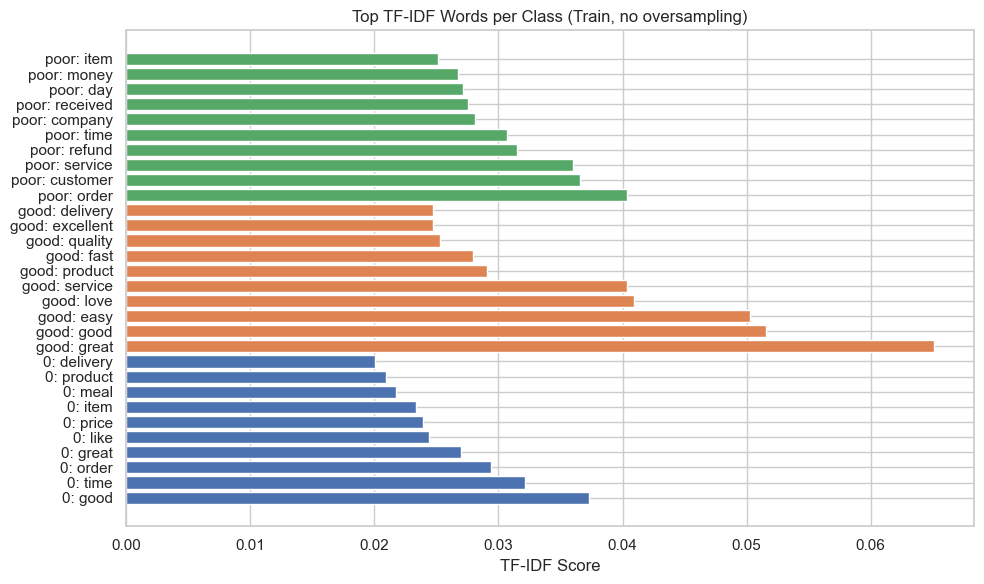

In [17]:
# Show top-10 TF-IDF words per class on the original training set
category_top_words = {}
for category in y_train.unique():
    indices = np.where(y_train == category)[0]
    mean_tfidf = X_train[indices].mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[::-1][:10]
    category_top_words[category] = [(feature_names[i], float(mean_tfidf[i])) for i in top_indices]

fig, ax = plt.subplots(figsize=(10, 6))
for category, words in category_top_words.items():
    labels, scores = zip(*words)
    ax.barh([f"{category}: {label}" for label in labels], scores)
ax.set_xlabel("TF-IDF Score")
ax.set_title("Top TF-IDF Words per Class (Train, no oversampling)")
plt.tight_layout()
plt.show()


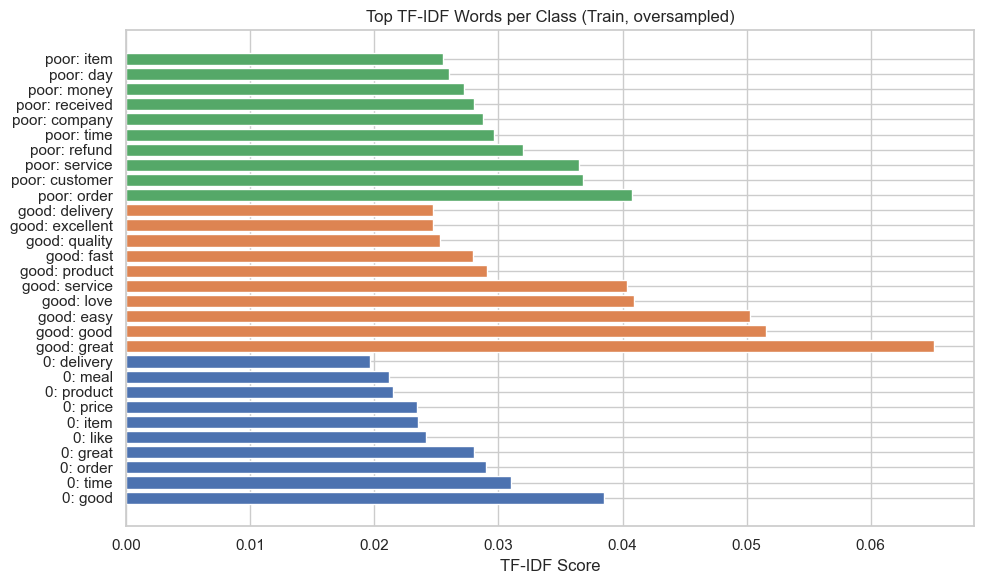

In [18]:
# Show top-10 TF-IDF words per class on the oversampled training set
category_top_words_over = {}
for category in y_resampled.unique():
    indices = np.where(y_resampled == category)[0]
    mean_tfidf = X_resampled[indices].mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[::-1][:10]
    category_top_words_over[category] = [
        (feature_names[i], float(mean_tfidf[i])) for i in top_indices
    ]

fig, ax = plt.subplots(figsize=(10, 6))
for category, words in category_top_words_over.items():
    labels, scores = zip(*words)
    ax.barh([f"{category}: {label}" for label in labels], scores)
ax.set_xlabel("TF-IDF Score")
ax.set_title("Top TF-IDF Words per Class (Train, oversampled)")
plt.tight_layout()
plt.show()
